# Notebook 4: Data Generation — CRN Motif Library

This notebook covers the `crn_surrogate.data.generation` sub-package, which provides:

- **8 canonical motif factories** — each encodes a biologically-motivated network topology
- **3 new propensity types** — Hill repression, combined activation-repression, and substrate inhibition
- **Parameter sampling** — log-uniform for rate constants, uniform for Hill coefficients
- **Viability curation** — filters degenerate dynamics before storing
- **Data generation pipeline** — end-to-end: sample → simulate → curate → save

By the end of this notebook we will have generated a small but usable training dataset.

In [1]:
import warnings
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 150, "font.size": 12, "axes.titlesize": 12})
TAB10 = plt.get_cmap("tab10").colors

## 1. New Propensity Types

Three new kinetic functions have been added to `crn_surrogate.crn.propensities`:

| Type | Formula | Use case |
|------|---------|----------|
| `hill_repression` | k_max / (1 + (X/K)^n) | Gene repression, negative feedback |
| `hill_activation_repression` | k_max · Hill_act(X_a) · Hill_rep(X_r) | Incoherent feedforward loop |
| `substrate_inhibition` | V_max · S / (K_m + S + S²/K_i) | Enzyme inhibited by excess substrate |

These complement the existing `hill` (activation), `mass_action`, `constant_rate`, and `enzyme_michaelis_menten` propensities.

In [ ]:
import torch
from crn_surrogate.crn.propensities import (
    hill_repression, hill_activation_repression, substrate_inhibition, hill,
)

x_vals = torch.linspace(0, 100, 300)

# --- Hill activation vs repression ---
p_act = hill(v_max=50.0, k_m=30.0, hill_coefficient=2.0, species_index=0)
p_rep = hill_repression(k_max=50.0, k_half=30.0, hill_coefficient=2.0, species_index=0)

act_rates = torch.stack([p_act(torch.tensor([x]), 0.0) for x in x_vals])
rep_rates = torch.stack([p_rep(torch.tensor([x]), 0.0) for x in x_vals])

# --- Substrate inhibition vs simple Michaelis-Menten ---
p_sub_inh = substrate_inhibition(v_max=50.0, k_m=20.0, k_i=60.0, species_index=0)
# MM equivalent (no inhibition term)
mm_rates = 50.0 * x_vals / (20.0 + x_vals + 1e-8)
sub_rates = torch.stack([p_sub_inh(torch.tensor([x]), 0.0) for x in x_vals])

# --- Combined activation-repression ---
# Activator fixed at 80, sweep repressor
x_act_fixed = torch.tensor([80.0, 0.0])
k_max, k_act, n_act, k_rep, n_rep = 50.0, 20.0, 2.0, 70.0, 2.0
p_combined = hill_activation_repression(
    k_max=k_max, k_act=k_act, n_act=n_act, activator_index=0,
    k_rep=k_rep, n_rep=n_rep, repressor_index=1,
)
# Fix activator at 80, sweep repressor 0..100
rep_sweep = torch.linspace(0, 100, 300)
combined_rates = torch.stack([
    p_combined(torch.tensor([80.0, r.item()]), 0.0)
    for r in rep_sweep
])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(x_vals, act_rates.detach(), color=TAB10[0], lw=2, label="Hill activation")
axes[0].plot(x_vals, rep_rates.detach(), color=TAB10[1], lw=2, label="Hill repression")
axes[0].axvline(30, color="gray", linestyle=":", lw=1, label="K = 30")
axes[0].set_xlabel("Species count X")
axes[0].set_ylabel("Propensity a(X)")
axes[0].set_title("Hill Activation vs Repression\n(k_max=50, K=30, n=2)")
axes[0].legend(fontsize=9)

axes[1].plot(x_vals, mm_rates.detach(), color=TAB10[2], lw=2, label="Michaelis-Menten")
axes[1].plot(x_vals, sub_rates.detach(), color=TAB10[3], lw=2, label="Substrate inhibition")
axes[1].axvline(60, color="gray", linestyle=":", lw=1, label="K_i = 60")
axes[1].set_xlabel("Substrate count S")
axes[1].set_ylabel("Propensity a(S)")
axes[1].set_title("Substrate Inhibition\n(V_max=50, K_m=20, K_i=60)")
axes[1].legend(fontsize=9)

axes[2].plot(rep_sweep, combined_rates.detach(), color=TAB10[4], lw=2)
axes[2].set_xlabel("Repressor count X_rep")
axes[2].set_ylabel("Propensity a(X)")
axes[2].set_title("Combined Act-Rep\n(activator fixed at 80)")
axes[2].text(0.05, 0.92, f"k_max={k_max}, K_act={k_act}, K_rep={k_rep}, n={n_rep}",
             transform=axes[2].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 2. Motif Catalogue

The generation library includes 8 canonical network motifs drawn from the systems biology literature. Each is implemented as a `MotifFactory` that returns a `CRN` object given a parameter dict.

| Motif | Species | Reactions | Key dynamics |
|-------|---------|-----------|-------------|
| Birth-death | 1 | 2 | Poisson stationary distribution |
| Auto-catalysis | 1 | 3 | Positive feedback, bistable regime |
| Negative autoregulation | 1 | 2 | Noise reduction, faster response |
| Toggle switch | 2 | 4 | Bistability (Gardner-Collins) |
| Enzymatic catalysis | 4 | 5 | Michaelis-Menten with explicit complex |
| Incoherent FFL | 3 | 6 | Pulse/adaptation response |
| Repressilator | 3 | 6 | Sustained oscillations (Elowitz & Leibler) |
| Substrate inhibition | 2 | 3 | Non-monotonic dose-response |

In [ ]:
from crn_surrogate.data.generation.motifs import (
    BirthDeathFactory, AutoCatalysisFactory, NegativeAutoregulationFactory,
    ToggleSwitchFactory, EnzymaticCatalysisFactory, IncoherentFeedforwardFactory,
    RepressilatorFactory, SubstrateInhibitionMotifFactory,
)

factories = [
    BirthDeathFactory(),
    AutoCatalysisFactory(),
    NegativeAutoregulationFactory(),
    ToggleSwitchFactory(),
    EnzymaticCatalysisFactory(),
    IncoherentFeedforwardFactory(),
    RepressilatorFactory(),
    SubstrateInhibitionMotifFactory(),
]

print(f"{'Motif':<30} {'Species':<25} {'n_rxn':>5}")
print("-" * 65)
for f in factories:
    print(f"  {f.motif_type.value:<28} {str(f.species_names):<25} {f.n_reactions:>5}")

## 3. Example Trajectories per Motif

We use the parameter sampler to draw one configuration per motif and run a small SSA ensemble to illustrate the characteristic dynamics.

In [ ]:
from crn_surrogate.data.generation.parameter_sampling import ParameterSampler
from crn_surrogate.data.generation.configs import SamplingConfig
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid
ssa = GillespieSSA()

T_MAX = 80.0
N_GRID = 200
N_TRAJ = 20
time_grid = torch.linspace(0, T_MAX, N_GRID)

# Fixed "interesting" params for each motif to ensure nice plots
fixed_params = [
    # BirthDeath
    {"k_prod": 10.0, "k_deg": 0.2},
    # AutoCatalysis
    {"k_basal": 1.0, "k_cat": 0.05, "k_deg": 0.1},
    # NegativeAutoregulation
    {"k_max": 40.0, "k_half": 20.0, "n_hill": 2.5, "k_deg": 0.15},
    # ToggleSwitch
    {"k_max_A": 50.0, "k_max_B": 50.0, "k_half_A": 25.0, "k_half_B": 25.0,
     "n_A": 3.0, "n_B": 3.0, "k_deg_A": 0.2, "k_deg_B": 0.2},
    # EnzymaticCatalysis
    {"k_on": 0.01, "k_off": 0.1, "k_cat": 0.3, "k_prod": 5.0, "k_deg_P": 0.1},
    # IncoherentFFL
    {"k_X": 5.0, "k_deg_X": 0.1, "k_max_Y": 20.0, "K_act_Y": 10.0, "n_act_Y": 2.0,
     "k_deg_Y": 0.15, "k_max_Z": 20.0, "K_act_Z": 10.0, "n_act_Z": 2.0,
     "K_rep_Z": 15.0, "n_rep_Z": 2.0, "k_deg_Z": 0.15},
    # Repressilator
    {"k_max_A": 80.0, "k_max_B": 80.0, "k_max_C": 80.0,
     "k_half_A": 20.0, "k_half_B": 20.0, "k_half_C": 20.0,
     "n_A": 3.0, "n_B": 3.0, "n_C": 3.0,
     "k_deg_A": 0.15, "k_deg_B": 0.15, "k_deg_C": 0.15},
    # SubstrateInhibition
    {"k_in": 5.0, "V_max": 20.0, "K_m": 15.0, "K_i": 60.0, "k_deg": 0.1},
]
fixed_initial_states = [
    # BirthDeath
    {"A": 0.0},
    # AutoCatalysis
    {"A": 5.0},
    # NegativeAutoregulation
    {"A": 0.0},
    # ToggleSwitch
    {"A": 20.0, "B": 20.0},
    # EnzymaticCatalysis
    {"S": 50.0, "E": 20.0, "C": 0.0, "P": 0.0},
    # IncoherentFFL
    {"X": 0.0, "Y": 0.0, "Z": 0.0},
    # Repressilator
    {"A": 30.0, "B": 0.0, "C": 0.0},
    # SubstrateInhibition
    {"S": 0.0, "P": 0.0},
]

print("Simulating example trajectories...")
all_trajs = {}
all_init = {}
for factory, params, initial_states in zip(factories, fixed_params, fixed_initial_states):
    params_inst = factory.params_type(**params)
    crn = factory.create(params_inst)
    init = torch.tensor([initial_states.get(n, 0.0) for n in factory.species_names], dtype=torch.float32)
    trajs = []
    for _ in range(N_TRAJ):
        res = ssa.simulate(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=init.clone(),
            t_max=T_MAX,
        )
        trajs.append(interpolate_to_grid(res.times, res.states, time_grid))
    all_trajs[factory.motif_type.value] = torch.stack(trajs)  # (N, T, n_species)
    all_init[factory.motif_type.value] = init
    print(f"  {factory.motif_type.value:<35} shape: {all_trajs[factory.motif_type.value].shape}")

In [ ]:
motif_labels = [
    ("birth_death",             "Birth-Death",                  ["A"]),
    ("auto_catalysis",          "Auto-Catalysis",               ["A"]),
    ("negative_autoregulation", "Negative Autoregulation",      ["A"]),
    ("toggle_switch",           "Toggle Switch",                ["A", "B"]),
    ("enzymatic_catalysis",     "Enzymatic Catalysis",          ["S", "E", "C", "P"]),
    ("incoherent_feedforward",  "Incoherent FFL",               ["X", "Y", "Z"]),
    ("repressilator",           "Repressilator",                ["A", "B", "C"]),
    ("substrate_inhibition",    "Substrate Inhibition",         ["S", "P"]),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()
t = time_grid.numpy()

for ax, (key, title, species) in zip(axes_flat, motif_labels):
    trajs = all_trajs[key]  # (N, T, n_sp)
    for sp_idx, sp_name in enumerate(species):
        color = TAB10[sp_idx % 10]
        # Individual trajectories (semi-transparent)
        for i in range(min(8, trajs.shape[0])):
            ax.plot(t, trajs[i, :, sp_idx].numpy(), alpha=0.15, lw=0.8, color=color)
        # Mean trajectory (solid)
        mean = trajs[:, :, sp_idx].mean(dim=0).numpy()
        ax.plot(t, mean, color=color, lw=2, label=sp_name)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=8)

plt.suptitle("Characteristic Dynamics — 8 CRN Motifs (20 SSA trajectories + mean)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Notes on each motif

- **Birth-death**: Poisson stationary distribution; mean = k_prod/k_deg = 50.
- **Auto-catalysis**: Positive feedback keeps A at a high stable level; initial population amplified by autocatalysis.
- **Negative autoregulation**: Hill repression creates a lower, tightly controlled steady state.
- **Toggle switch**: Bistability — from a high-A/low-B initial condition, A dominates; mutual repression locks in the state.
- **Enzymatic catalysis**: Complex C forms and turns over rapidly; product P accumulates at the rate set by k_cat.
- **Incoherent FFL**: Z shows an early pulse (X activates directly), then settles lower once Y (the repressor) builds up.
- **Repressilator**: Three-node ring oscillator with cooperative repression drives sustained oscillations in A, B, C out of phase.
- **Substrate inhibition**: S builds up until it inhibits its own conversion; steady state S is set by the balance of influx and inhibited catalysis.

## 4. Parameter Sampling

The `ParameterSampler` draws kinetic parameters from the ranges defined by each `MotifFactory`:

- **Rate constants** (`k_*`): log-uniform sampling — equal probability per decade
- **Hill coefficients** (`n_*`): uniform sampling — they live in a narrow range (1–5)
- **Initial states**: uniform integer sampling

Motif-specific constraints (e.g. k_deg > k_cat for auto-catalysis) are enforced by rejection sampling.

In [ ]:
from crn_surrogate.data.generation.parameter_sampling import ParameterSampler
from crn_surrogate.data.generation.configs import SamplingConfig

sampler = ParameterSampler(SamplingConfig(random_seed=0))

# Sample 1000 configs for birth-death and toggle switch
bd_params = sampler.sample(BirthDeathFactory(), n_samples=1000)
ts_params = sampler.sample(ToggleSwitchFactory(), n_samples=1000)

# --- Marginal histograms ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

# Birth-death: k_prod and k_deg on log scale
k_prod_vals = [p.k_prod for p in bd_params]
k_deg_vals  = [p.k_deg  for p in bd_params]
axes[0].hist(np.log10(k_prod_vals), bins=30, color=TAB10[0], alpha=0.8)
axes[0].set_xlabel("log₁₀(k_prod)")
axes[0].set_title("Birth-Death: k_prod\n(log-uniform ∈ [0.5, 50])")
axes[1].hist(np.log10(k_deg_vals), bins=30, color=TAB10[1], alpha=0.8)
axes[1].set_xlabel("log₁₀(k_deg)")
axes[1].set_title("Birth-Death: k_deg\n(log-uniform ∈ [0.01, 1])")

# Toggle switch: n_A (Hill coeff, uniform) and k_half_A (log-uniform)
n_A_vals    = [p.n_A     for p in ts_params]
k_half_vals = [p.k_half_A for p in ts_params]
axes[2].hist(n_A_vals, bins=25, color=TAB10[2], alpha=0.8)
axes[2].set_xlabel("n_A (Hill coefficient)")
axes[2].set_title("Toggle Switch: n_A\n(uniform ∈ [2, 4])")
axes[3].hist(np.log10(k_half_vals), bins=25, color=TAB10[3], alpha=0.8)
axes[3].set_xlabel("log₁₀(k_half_A)")
axes[3].set_title("Toggle Switch: k_half_A\n(log-uniform ∈ [10, 50])")

for ax in axes:
    ax.set_ylabel("Count")
plt.suptitle("Marginal parameter distributions", y=1.02)
plt.tight_layout()
plt.show()

# --- Joint scatter plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Birth-death: log k_prod vs log k_deg
axes[0].scatter(
    np.log10(k_prod_vals), np.log10(k_deg_vals),
    s=4, alpha=0.3, color=TAB10[0],
)
axes[0].set_xlabel("log₁₀(k_prod)")
axes[0].set_ylabel("log₁₀(k_deg)")
axes[0].set_title("Birth-Death\njoint (k_prod, k_deg)")

# Toggle switch: n_A vs log k_half_A
axes[1].scatter(
    n_A_vals, np.log10(k_half_vals),
    s=4, alpha=0.3, color=TAB10[2],
)
axes[1].set_xlabel("n_A (Hill coefficient)")
axes[1].set_ylabel("log₁₀(k_half_A)")
axes[1].set_title("Toggle Switch\njoint (n_A, k_half_A)")

# Toggle switch: log k_max_A vs log k_deg_A
k_max_A_vals = [p.k_max_A for p in ts_params]
k_deg_A_vals = [p.k_deg_A for p in ts_params]
axes[2].scatter(
    np.log10(k_max_A_vals), np.log10(k_deg_A_vals),
    s=4, alpha=0.3, color=TAB10[3],
)
axes[2].set_xlabel("log₁₀(k_max_A)")
axes[2].set_ylabel("log₁₀(k_deg_A)")
axes[2].set_title("Toggle Switch\njoint (k_max_A, k_deg_A)")

plt.suptitle("Joint parameter distributions (scatter)", y=1.02)
plt.tight_layout()
plt.show()

# --- Verify autocatalysis constraint ---
ac_factory = AutoCatalysisFactory()
ac_params = sampler.sample(ac_factory, n_samples=500)
violations = sum(1 for p in ac_params if p.k_cat >= p.k_deg)
print(f"Auto-catalysis constraint violations (k_cat >= k_deg): {violations}/500")
print(f"  Mean k_cat: {np.mean([p.k_cat for p in ac_params]):.4f}")
print(f"  Mean k_deg: {np.mean([p.k_deg for p in ac_params]):.4f}")

# Scatter: k_cat vs k_deg (log scale) — constraint boundary is the diagonal
k_cat_vals = [p.k_cat for p in ac_params]
k_deg_vals_ac = [p.k_deg for p in ac_params]
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(np.log10(k_cat_vals), np.log10(k_deg_vals_ac), s=4, alpha=0.4, color=TAB10[4])
lims = [min(np.log10(k_cat_vals + k_deg_vals_ac)), max(np.log10(k_cat_vals + k_deg_vals_ac))]
ax.plot(lims, lims, 'k--', lw=1, label="k_cat = k_deg boundary")
ax.set_xlabel("log₁₀(k_cat)")
ax.set_ylabel("log₁₀(k_deg)")
ax.set_title("Auto-Catalysis: joint (k_cat, k_deg)\nall valid samples lie above the diagonal")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Viability Curation

Before storing a CRN configuration, the `ViabilityFilter` runs 6 checks on the SSA ensemble:

| Criterion | What it detects |
|-----------|----------------|
| NaN / Inf | Numerical instability |
| Blowup (> 10⁶) | Supercritical growth |
| Zero-stuck (> 95% zeros) | Network never fires |
| Low activity (< 10 transitions) | Network freezes immediately |
| Low CV (< 0.01) | Effectively deterministic — no stochasticity to learn |
| Unbounded final state (> 10⁵ mean) | Slow blowup |

Only configurations passing ALL checks are kept.

In [ ]:
from crn_surrogate.data.generation.curation import ViabilityFilter, CurationResult
from crn_surrogate.data.generation.configs import CurationConfig

filt = ViabilityFilter(CurationConfig())

# Helper: make a (4, 50, 1) fake trajectory batch
def make_trajs(values):
    """values: list/array of shape (T,) -> broadcast to (4, T, 1)"""
    v = torch.tensor(values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    return v.expand(4, -1, -1)

t_grid = torch.linspace(0, 20, 50)

test_cases = [
    ("Good (birth-death)", None),          # will simulate for real below
    ("Blowup",        make_trajs([float(i * 1e5) for i in range(50)])),
    ("All zeros",     make_trajs([0.0] * 50)),
    ("Low activity",  make_trajs([10.0] * 50)),    # constant = no transitions
    ("Near-constant", make_trajs([100.0 + 0.001 * i for i in range(50)])),
    ("Huge final",    make_trajs([i * 4000.0 for i in range(50)])),
]

# Simulate a real birth-death trajectory for the "good" case
bd = BirthDeathFactory().create(BirthDeathFactory().params_type(k_prod= 10.0, k_deg=0.2))
bd_trajs_list = []
for _ in range(4):
    res = ssa.simulate(
        stoichiometry=bd.stoichiometry_matrix,
        propensity_fn=bd.evaluate_propensities,
        initial_state=torch.tensor([0.0]),
        t_max=20.0,
    )
    bd_trajs_list.append(interpolate_to_grid(res.times, res.states, t_grid))
good_trajs = torch.stack(bd_trajs_list)  # (4, 50, 1)

print(f"{'Test case':<25}  {'Viable?':<8}  Reason")
print("-" * 55)
for name, trajs in test_cases:
    if trajs is None:
        trajs = good_trajs
    result = filt.check(trajs)
    status = "\u2713 PASS" if result.viable else "\u2717 FAIL"
    print(f"  {name:<23}  {status:<8}  {result.rejection_reason or '\u2014'}")

## 6. Generating a Small Training Dataset

Now we run the full pipeline. For demonstration, we use reduced counts (30 samples per motif, 8 SSA trajectories, 60 time points). This produces a dataset in ~2–5 minutes.

For a full training dataset, use the defaults: `n_samples_per_motif=500`, `n_ssa_trajectories=32`, `n_timepoints=200`.

In [2]:
import logging
import time
from pathlib import Path
from crn_surrogate.data.generation import (
    DataGenerationPipeline,
    GenerationConfig,
    SamplingConfig,
    CurationConfig,
    all_elementary_tasks,
    GenerationTask,
)
from crn_surrogate.data.generation.motifs import IncoherentFeedforwardFactory

# Set to True to regenerate even if the dataset file already exists on disk.
FORCE_REGENERATE = False

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(name)s  %(message)s")

config = GenerationConfig(
    sampling=SamplingConfig(random_seed=42),
    curation=CurationConfig(),
    n_ssa_trajectories=8,
    simulation_time=50.0,
    n_timepoints=100,
    batch_size=16,
    max_attempts_multiplier=5,
    output_dir="data_cache/demo_dataset",
    random_seed=42,
)

_dataset_path = Path(config.output_dir) / "dataset.pt"

if not FORCE_REGENERATE and _dataset_path.exists():
    print(f"Dataset already exists at {_dataset_path} — skipping generation.")
    print("Set FORCE_REGENERATE = True to regenerate from scratch.")
    summary = None
else:
    tasks = all_elementary_tasks(target_per_motif=30)
    # tasks = [GenerationTask(factory=IncoherentFeedforwardFactory(), target=30)]
    pipeline = DataGenerationPipeline(config, tasks=tasks)
    t0 = time.time()
    summary = pipeline.run()
    elapsed = time.time() - t0
    print(f"Generation complete in {elapsed:.1f}s")
    print(f"Total viable items: {summary.total_items}")

INFO  crn_surrogate.data.generation.pipeline  birth_death: 30/30 viable in 36 attempts (83.3% pass rate)
INFO  crn_surrogate.data.generation.pipeline  auto_catalysis: 30/30 viable in 47 attempts (63.8% pass rate)
INFO  crn_surrogate.data.generation.pipeline  negative_autoregulation: 30/30 viable in 51 attempts (58.8% pass rate)
INFO  crn_surrogate.data.generation.pipeline  toggle_switch: 30/30 viable in 35 attempts (85.7% pass rate)
INFO  crn_surrogate.data.generation.pipeline  enzymatic_catalysis: 30/30 viable in 32 attempts (93.8% pass rate)
INFO  crn_surrogate.data.generation.pipeline  incoherent_feedforward: 30/30 viable in 34 attempts (88.2% pass rate)
INFO  crn_surrogate.data.generation.pipeline  repressilator: 30/30 viable in 33 attempts (90.9% pass rate)
INFO  crn_surrogate.data.generation.pipeline  substrate_inhibition: 30/30 viable in 37 attempts (81.1% pass rate)
WARNING  crn_surrogate.data.generation.pipeline  Motif 'birth_death' has only 30 viable configs (< 50)
WARNING  c

Generation complete in 1910.0s
Total viable items: 240


In [3]:
import collections
import json as _json
from pathlib import Path
import torch
from crn_surrogate.data.dataset import CRNTrajectoryDataset
from crn_surrogate.data.generation.pipeline import DatasetSummary

# Load summary from metadata.json when dataset was loaded from cache
if summary is None:
    _meta_path = _dataset_path.parent / "metadata.json"
    with open(_meta_path) as _f:
        _meta = _json.load(_f)
    summary = DatasetSummary(
        total_items=_meta["total_items"],
        counts_per_motif=_meta["counts_per_motif"],
        curation_stats=_meta["curation_stats"],
        cluster_id_map=_meta["cluster_id_map"],
    )

dataset = CRNTrajectoryDataset(_dataset_path)
print(f"Dataset loaded: {len(dataset)} items")

# --- Shape, finiteness, and metadata checks ---
errors = []
for i, item in enumerate(dataset):
    M, T, S = item.trajectories.shape
    if S != item.crn_repr.n_species:
        errors.append(f"Item {i}: trajectory species dim {S} != crn_repr.n_species {item.crn_repr.n_species}")
    if item.times.shape != (T,):
        errors.append(f"Item {i}: times shape {item.times.shape} != ({T},)")
    if item.initial_state.shape != (S,):
        errors.append(f"Item {i}: initial_state shape {item.initial_state.shape} != ({S},)")
    if not torch.isfinite(item.trajectories).all():
        errors.append(f"Item {i}: trajectories contain non-finite values")
    if item.cluster_id < 0:
        errors.append(f"Item {i}: cluster_id not assigned ({item.cluster_id})")
    if not item.motif_label:
        errors.append(f"Item {i}: empty motif_label")

if errors:
    print(f"FAILED — {len(errors)} error(s) found:")
    for e in errors[:10]:
        print(f"  x {e}")
else:
    print("All shape / finiteness / metadata checks passed.")

# --- Per-motif item count ---
counts = collections.Counter(item.motif_label for item in dataset)
print(f"{'Motif':<40} {'Count':>6}")
print("-" * 48)
for label, count in sorted(counts.items()):
    print(f"{label:<40} {count:>6}")

# --- Spot-check one item ---
item0 = dataset[0]
traj = item0.trajectories  # (M, T, n_species)
print(f"Sample item — motif: {item0.motif_label!r}, cluster_id: {item0.cluster_id}")
print(f"  trajectories shape : {tuple(traj.shape)}  (M, T, n_species)")
print(f"  times              : {item0.times[0]:.1f} -> {item0.times[-1]:.1f}")
print(f"  trajectory mean    : {traj.mean():.3f}")
print(f"  trajectory std     : {traj.std():.3f}")
print(f"  params             : { {k: f'{v:.3g}' for k, v in item0.params.items()} }")


Dataset loaded: 240 items
All shape / finiteness / metadata checks passed.
Motif                                     Count
------------------------------------------------
auto_catalysis                               30
birth_death                                  30
enzymatic_catalysis                          30
incoherent_feedforward                       30
negative_autoregulation                      30
repressilator                                30
substrate_inhibition                         30
toggle_switch                                30
Sample item — motif: 'birth_death', cluster_id: 1
  trajectories shape : (8, 100, 1)  (M, T, n_species)
  times              : 0.0 -> 50.0
  trajectory mean    : 89.062
  trajectory std     : 41.683
  params             : {'k_prod': '2.99', 'k_deg': '0.00015'}


In [4]:
print("\nCuration statistics per motif:")
print(f"  {'Motif':<35} {'Sampled':>8} {'Passed':>8} {'Pass %':>8}  Rejection breakdown")
print("  " + "-" * 80)
for label, stats in summary.curation_stats.items():
    n = stats["n_sampled"]
    p = stats["n_passed"]
    rate = 100 * p / n if n > 0 else 0.0
    rejections = {k: v for k, v in stats.items()
                  if k not in ("n_sampled", "n_passed", "n_rejected") and v > 0}
    rej_str = ", ".join(f"{k}={v}" for k, v in rejections.items()) if rejections else "\u2014"
    print(f"  {label:<35} {n:>8} {p:>8} {rate:>7.0f}%  {rej_str}")

print(f"\nCluster ID map: {summary.cluster_id_map}")


Curation statistics per motif:
  Motif                                Sampled   Passed   Pass %  Rejection breakdown
  --------------------------------------------------------------------------------
  birth_death                               36       30      83%  low_activity=3, zero_stuck=3
  auto_catalysis                            47       30      64%  zero_stuck=17
  negative_autoregulation                   51       30      59%  zero_stuck=17, low_activity=4
  toggle_switch                             35       30      86%  low_activity=1, zero_stuck=4
  enzymatic_catalysis                       32       30      94%  low_activity=2
  incoherent_feedforward                    34       30      88%  zero_stuck=2, low_activity=2
  repressilator                             33       30      91%  zero_stuck=3
  substrate_inhibition                      37       30      81%  zero_stuck=2, low_activity=5

Cluster ID map: {'auto_catalysis': 0, 'birth_death': 1, 'enzymatic_catalysis': 2, 

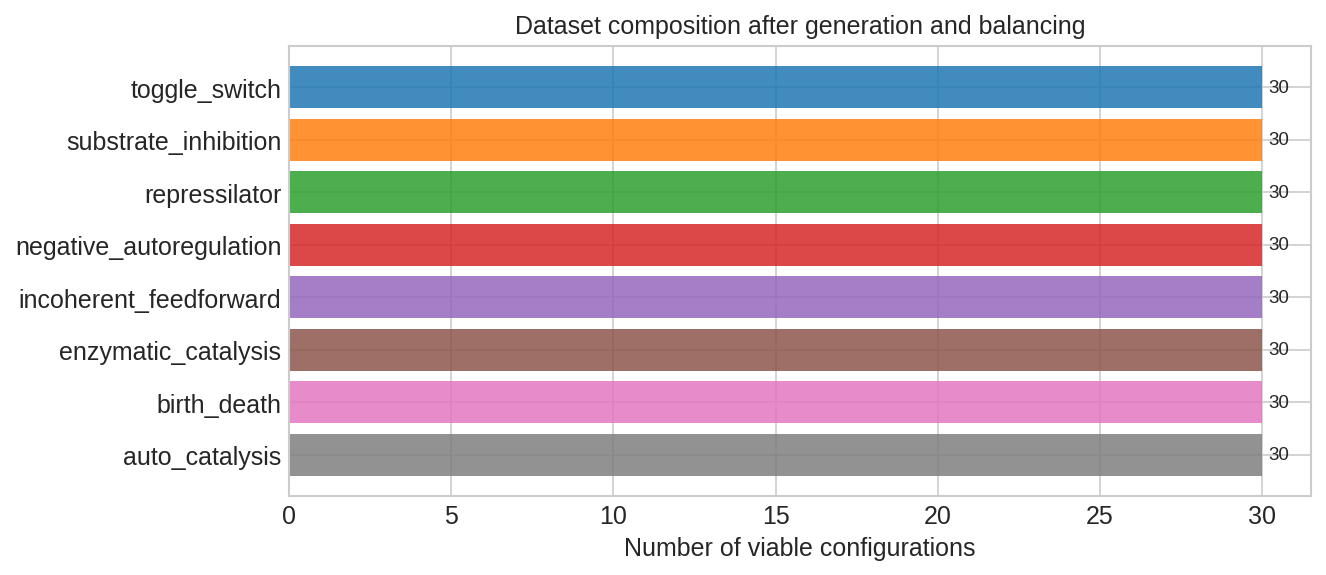

In [5]:
labels = list(summary.counts_per_motif.keys())
counts = list(summary.counts_per_motif.values())
sorted_pairs = sorted(zip(counts, labels), reverse=True)
counts_s, labels_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels_s, counts_s, color=[TAB10[i % 10] for i in range(len(labels_s))], alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of viable configurations")
ax.set_title("Dataset composition after generation and balancing")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Loading and Inspecting the Dataset

The dataset is saved as a `.pt` file containing a list of `TrajectoryItem` objects. `CRNTrajectoryDataset` can load it directly from the file path.

In [6]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, CRNCollator
from torch.utils.data import DataLoader

dataset = CRNTrajectoryDataset("data_cache/demo_dataset/dataset.pt")
print(f"Dataset size: {len(dataset)}")

item = dataset[0]
print(f"\nFirst item:")
print(f"  motif_label:          {item.motif_label}")
print(f"  cluster_id:           {item.cluster_id}")
print(f"  n_species:            {item.crn_repr.n_species}")
print(f"  n_reactions:          {item.crn_repr.n_reactions}")
print(f"  trajectories shape:   {item.trajectories.shape}  (M, T, n_species)")
print(f"  times shape:          {item.times.shape}")
print(f"  params:               { {k: f'{v:.3g}' for k, v in item.params.items()} }")
print(f"\nPropensity type IDs:   {item.crn_repr.propensity_type_ids.tolist()}")
print(f"Stoichiometry matrix:\n{item.crn_repr.stoichiometry}")

Dataset size: 240

First item:
  motif_label:          birth_death
  cluster_id:           1
  n_species:            1
  n_reactions:          2
  trajectories shape:   torch.Size([8, 100, 1])  (M, T, n_species)
  times shape:          torch.Size([100])
  params:               {'k_prod': '2.99', 'k_deg': '0.00015'}

Propensity type IDs:   [2, 0]
Stoichiometry matrix:
tensor([[ 1.],
        [-1.]])


In [7]:
collator = CRNCollator()
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collator)

batch = next(iter(loader))
print("Batch keys and shapes:")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:<25} {tuple(v.shape)}")
    else:
        print(f"  {k:<25} {v}")

print(f"\ncluster_ids in batch: {batch['cluster_ids'].tolist()}")
print(f"species_mask sum:     {batch['species_mask'].sum(dim=1).tolist()}  (n_species per item)")
print(f"reaction_mask sum:    {batch['reaction_mask'].sum(dim=1).tolist()}  (n_reactions per item)")

Batch keys and shapes:
  stoichiometry             (4, 6, 3)
  dependency_matrix         (4, 6, 3)
  propensity_params         (4, 6, 8)
  propensity_type_ids       (4, 6)
  initial_states            (4, 3)
  trajectories              (4, 8, 100, 3)
  times                     (4, 100)
  species_mask              (4, 3)
  reaction_mask             (4, 6)
  cluster_ids               (4,)

cluster_ids in batch: [6, 1, 5, 4]
species_mask sum:     [2, 1, 3, 1]  (n_species per item)
reaction_mask sum:    [3, 2, 6, 2]  (n_reactions per item)


## 8. Dataset Diversity Visualizations

Let's confirm the dataset covers diverse dynamical regimes.

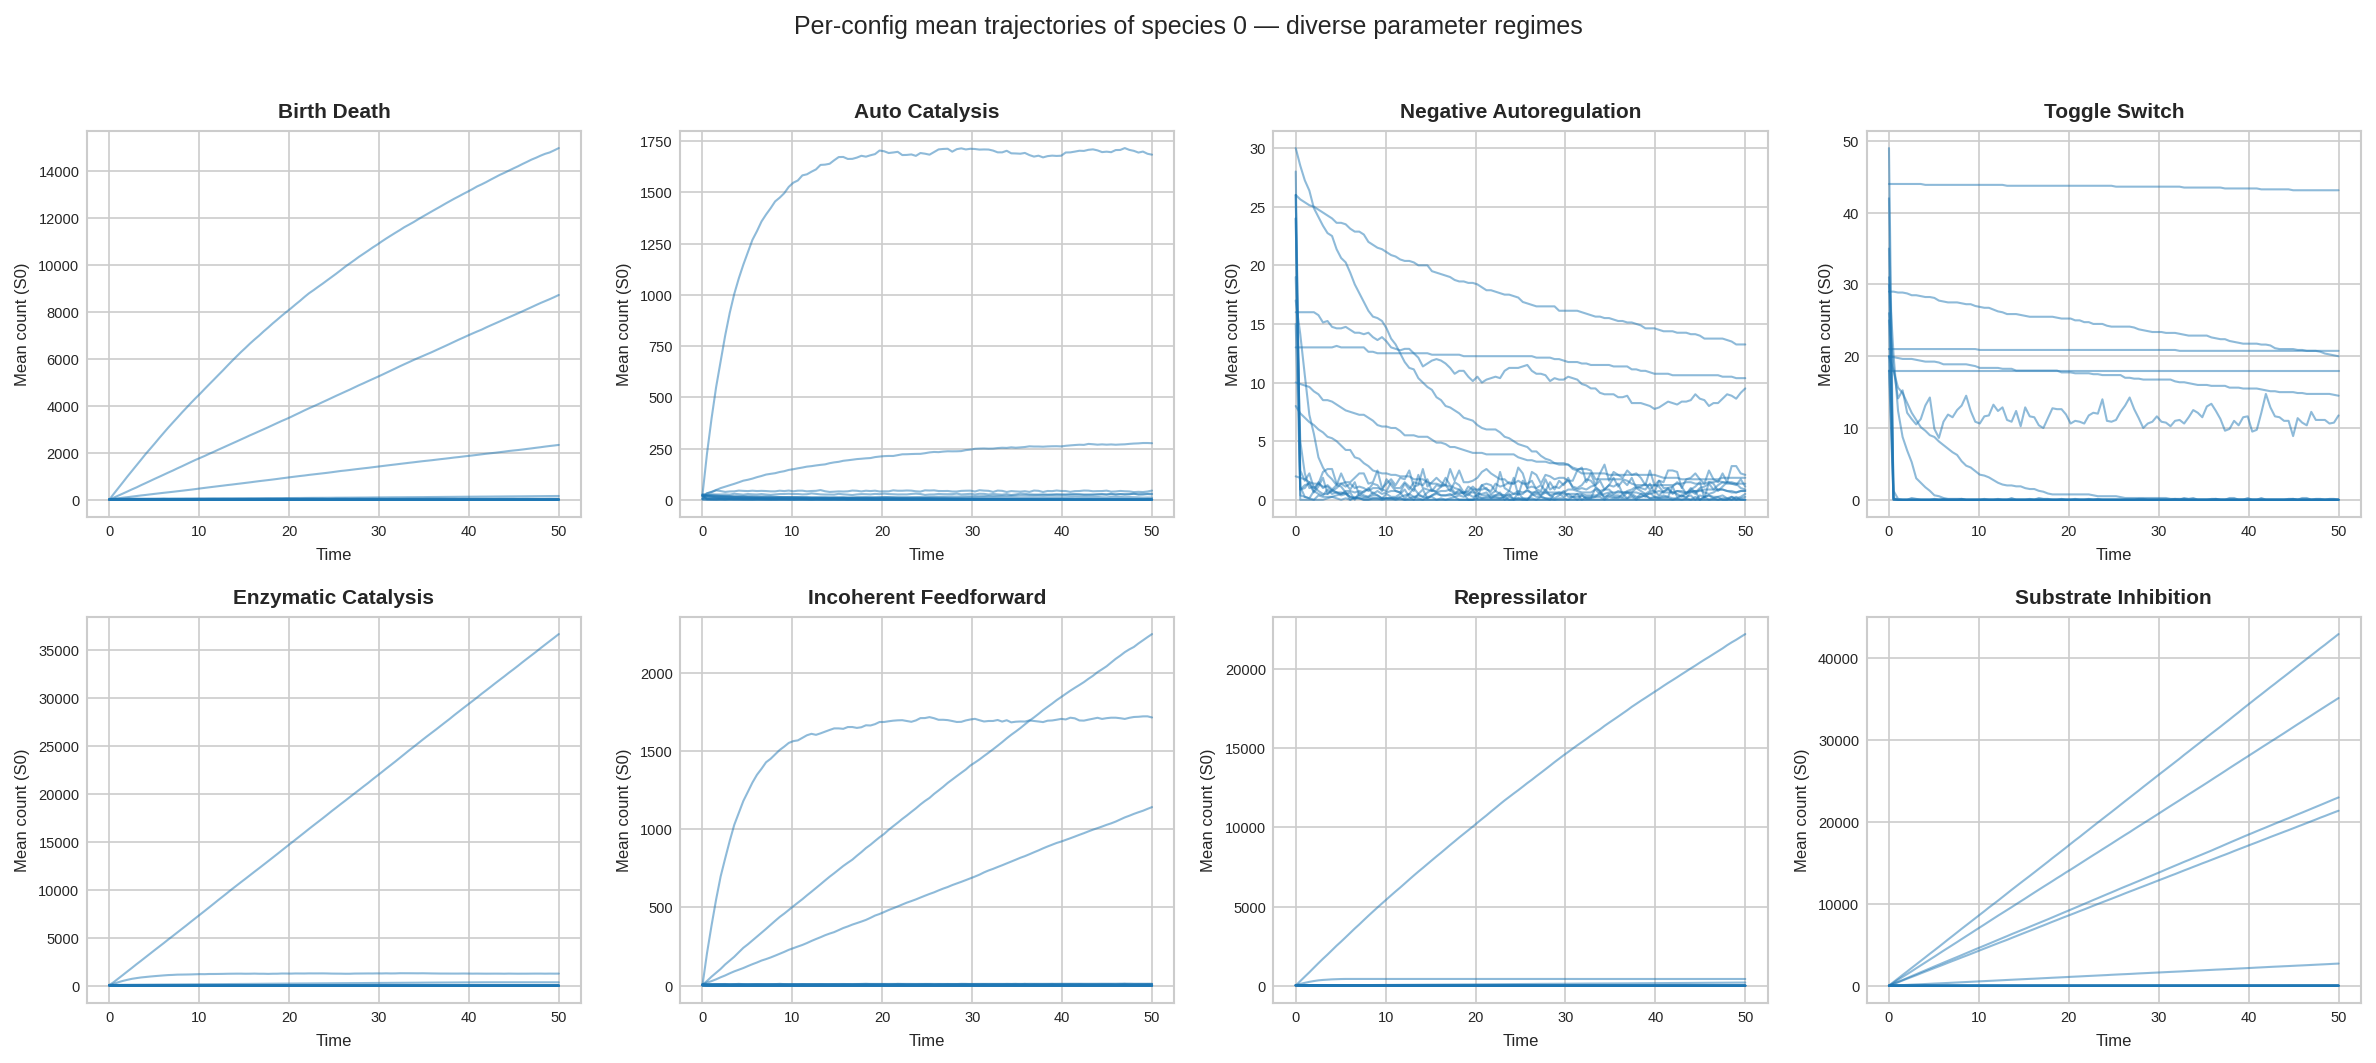

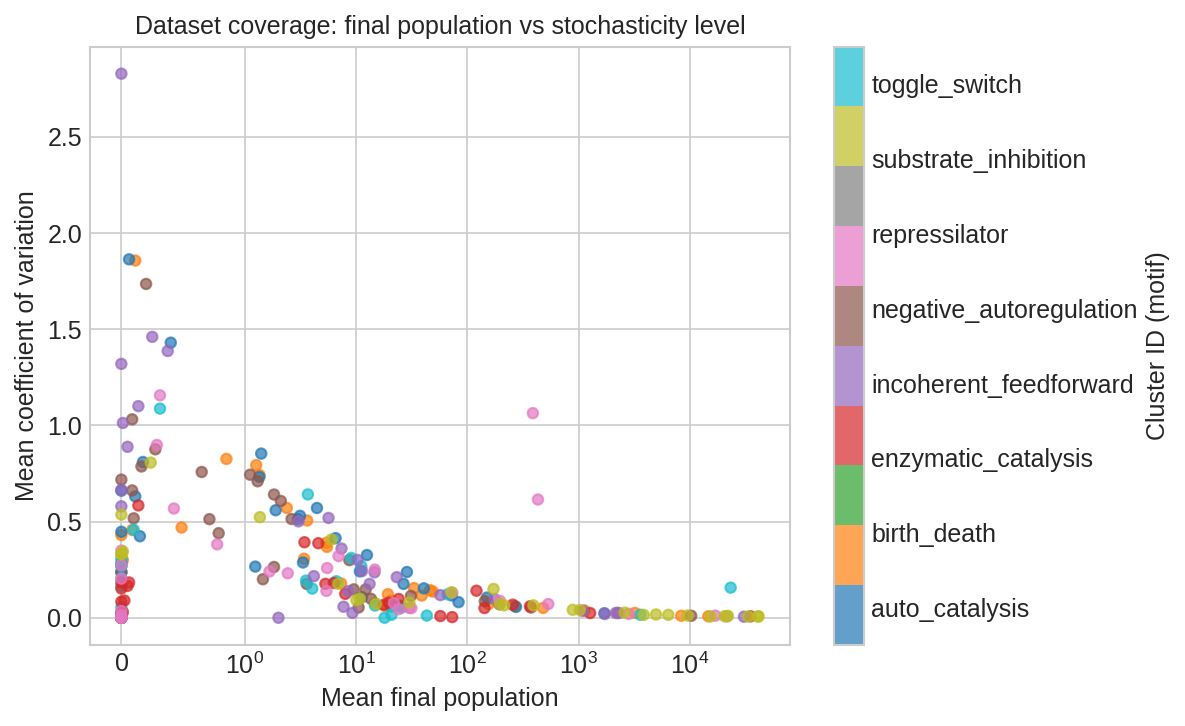

In [8]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset

dataset = CRNTrajectoryDataset("data_cache/demo_dataset/dataset.pt")

# Group items by motif label
by_label: dict[str, list] = {}
for item in dataset:
    by_label.setdefault(item.motif_label, []).append(item)

# For each motif, plot the mean trajectory of species 0 across all configs
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes_flat = axes.flatten()

for ax, (label, items) in zip(axes_flat, by_label.items()):
    t = items[0].times.numpy()
    for item in items[:15]:  # up to 15 configs
        mean_traj = item.trajectories[:, :, 0].mean(dim=0).numpy()
        ax.plot(t, mean_traj, alpha=0.5, lw=1.0, color=TAB10[0])
    ax.set_title(label.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Time", fontsize=8)
    ax.set_ylabel("Mean count (S0)", fontsize=8)
    ax.tick_params(labelsize=7)

# Hide any unused axes
for ax in axes_flat[len(by_label):]:
    ax.set_visible(False)

plt.suptitle(
    "Per-config mean trajectories of species 0 — diverse parameter regimes",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

# Final state scatter: mean final population vs CV
final_means, final_cvs, cluster_ids_list = [], [], []
for item in dataset:
    traj = item.trajectories[:, :, 0]  # (M, T)
    final_mean = traj[:, -10:].mean().item()
    cv = (traj.std(dim=0).mean() / (traj.mean() + 1e-8)).item()
    final_means.append(final_mean)
    final_cvs.append(cv)
    cluster_ids_list.append(item.cluster_id)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    final_means, final_cvs,
    c=cluster_ids_list, cmap="tab10", alpha=0.7, s=25,
    vmin=-0.5, vmax=max(cluster_ids_list) + 0.5,
)
cbar = plt.colorbar(scatter, ax=ax, ticks=sorted(set(cluster_ids_list)))
cbar.set_label("Cluster ID (motif)")
cbar.set_ticklabels([summary.cluster_id_map and {v: k for k, v in summary.cluster_id_map.items()}.get(i, str(i)) for i in sorted(set(cluster_ids_list))])
ax.set_xlabel("Mean final population")
ax.set_ylabel("Mean coefficient of variation")
ax.set_title("Dataset coverage: final population vs stochasticity level")
ax.set_xscale("symlog", linthresh=1)
plt.tight_layout()
plt.show()

## 9. Full-Scale Dataset (Optional)

To generate a production-scale dataset (~15 000 viable items), use the default config:

```python
from crn_surrogate.data.generation import DataGenerationPipeline, GenerationConfig

config = GenerationConfig(
    n_samples_per_motif=500,
    n_ssa_trajectories=32,
    simulation_time=100.0,
    n_timepoints=200,
    output_dir="data_cache/full_dataset",
)
summary = DataGenerationPipeline(config).run()
print(f"Generated {summary.total_items} items")
```

Expected pass rates (rough estimates from the curation criteria):
- Birth-death: ~90% pass rate
- Auto-catalysis: ~70% (constraint k_deg > k_cat reduces sample pool)
- Toggle switch: ~75%
- Repressilator: ~60% (requires cooperativity n ≥ 2 AND initial asymmetry)
- Others: ~80–85%

The balancing step caps any over-represented class at 2× the median count, so the final dataset will be roughly uniform across motifs.

Once generated, load with:

```python
from crn_surrogate.data.dataset import CRNTrajectoryDataset

full_dataset = CRNTrajectoryDataset("data_cache/full_dataset/dataset.pt")
```

## Summary of Changes

This notebook demonstrated the following additions to the `crn_surrogate` codebase:

### New propensity types (`crn_surrogate.crn.propensities`)
| Factory | Params | Tensor layout (8 slots) |
|---------|--------|------------------------|
| `hill_repression(k_max, k_half, n, idx)` | `HillRepressionParams` | `[k_max, k_half, n, idx, 0, 0, 0, 0]` |
| `hill_activation_repression(...)` | `HillActivationRepressionParams` | `[k_max, k_act, n_act, act_idx, k_rep, n_rep, rep_idx, 0]` |
| `substrate_inhibition(V_max, K_m, K_i, idx)` | `SubstrateInhibitionParams` | `[V_max, K_m, K_i, idx, 0, 0, 0, 0]` |

### Updated `PropensityType` enum (`crn_surrogate.encoder.tensor_repr`)
Added: `HILL_REPRESSION=4`, `HILL_ACTIVATION_REPRESSION=5`, `SUBSTRATE_INHIBITION=6`

### Updated defaults
- `EncoderConfig.max_propensity_params`: 4 → **8**
- `EncoderConfig.n_propensity_types`: 4 → **7**

### Extended `TrajectoryItem` (`crn_surrogate.data.dataset`)
Added optional fields: `motif_label: str`, `cluster_id: int`, `params: dict`

`CRNTrajectoryDataset` now also accepts a file path. `CRNCollator` now returns `cluster_ids` in the batch dict.

### New sub-package: `crn_surrogate.data.generation`
- `MotifType` enum — 8 canonical motifs
- `MotifFactory` ABC + 8 concrete factories
- `ParameterSampler` — log-uniform rates, uniform Hill coefficients, rejection sampling
- `ViabilityFilter` + `CurationResult` — 6-criterion curation
- `CRNComposer` — compose two CRNs by merging shared species
- `DataGenerationPipeline` — orchestrates sample → simulate → curate → balance → save